# Regularization in Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

<h3 style = 'color: red'>Define a function to display evaluation metrics</h3>

In [2]:
def regression_results(y_true, y_pred, regression_type):
    # regression metrics
    ev = explained_variance_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print('Evaluation metrics for' + regression_type + 'Linear Regression')
    print('Explained_variance: ', round(ev, 4))
    print('r2: ', round(r2, 4))
    print('MAE: ', round(mae, 4))
    print('MSE: ', round(mse, 4))
    print('RMSE', round(np.sqrt(mse), 4))

<h3 style = 'color: red'>Generate a simple dataset with one feature using numpy</h3>

In [3]:
#generate synthetic data
noise = 1
np.random.seed(42)
x = 2 * np.random.rand(1000, 1)
y = 4 + 3 * x + noise * np.random.randn(1000, 1)     # linear relationship with some noise
y_ideal = 4 + 3 * x
# specify the portion of the dataset to add outliers (the last 20%)
y_outlier = pd.Series(y.reshape(-1).copy())      # copy function is used here becuz the original y cant be changed
# identify indices where the feature variable x is greater than a certain threshold
threshold = 1.5
outlier_indices = np.where(x.flatten() > threshold)[0]
# add outliers at random locations within the specified portion
num_outliers = 5
selected_indices = np.random.choice(outlier_indices, num_outliers, replace = False)
# modify the target values at these indices to create outliers (add significant noise)
y_outlier[selected_indices] += np.random.uniform(50, 100, num_outliers)

<h3 style = 'color: red'>Plot the data with outliers and the ideal fit line</h3>

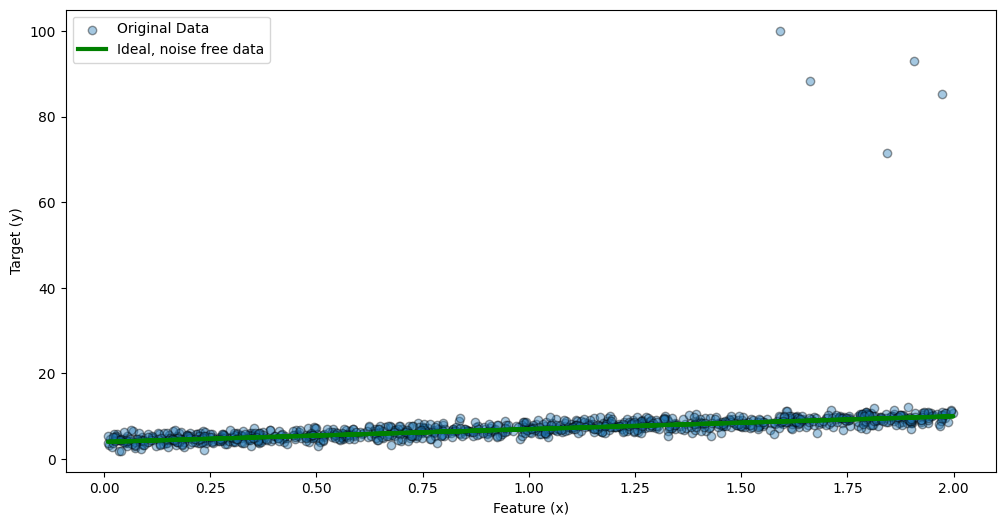

In [4]:
plt.figure(figsize = (12, 6))
# scatter plot of the original data with outliers
plt.scatter(x, y_outlier, alpha = 0.4, ec = 'k', label = 'Original Data')
plt.plot(x, y_ideal, linewidth = 3, color = 'g', label = 'Ideal, noise free data')
plt.xlabel('Feature (x)')
plt.ylabel('Target (y)')
plt.legend()
plt.show()

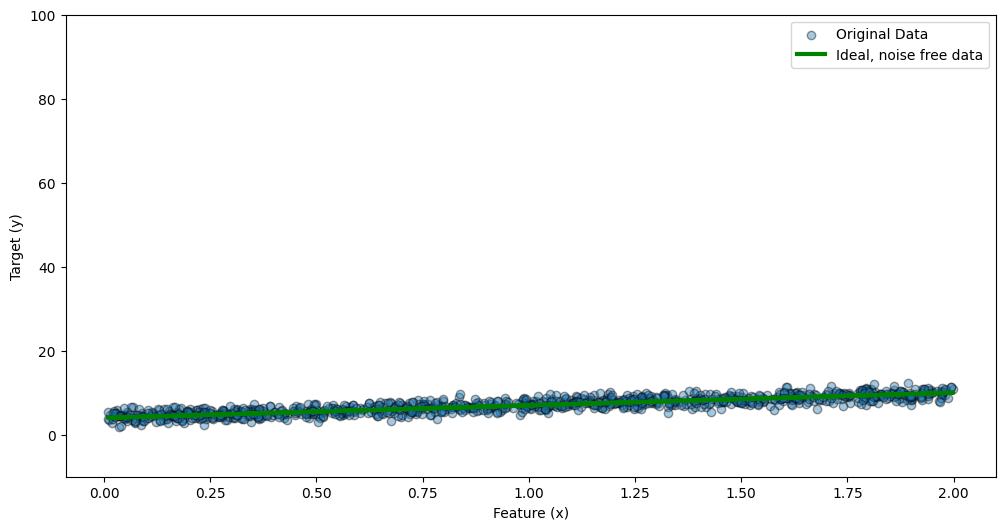

In [5]:
plt.figure(figsize = (12, 6))
# scatter plot of the original data with outliers
plt.scatter(x, y, alpha = 0.4, ec = 'k', label = 'Original Data')
plt.plot(x, y_ideal, linewidth = 3, color = 'g', label = 'Ideal, noise free data')
plt.xlabel('Feature (x)')
plt.ylabel('Target (y)')
plt.ylim([-10, 100])
plt.legend()
plt.show()

<h3 style = 'color: red'>Fit Ordinary, Ridge, and Lasso Regression Models</h3>
<h3 style = 'color: red'>Visualize the performance of models with the effect of outliers</h3>

In [6]:
# fit a simple linear regression model
lin_reg = LinearRegression()
lin_reg.fit(x, y_outlier)
y_hat_OLS = lin_reg.predict(x)
# fit a ridge regression model (regularization to control large coefficients)
ridge_reg = Ridge(alpha = 1)
ridge_reg.fit(x, y_outlier)
y_hat_ridge = ridge_reg.predict(x)
# fit a lasso regression model (regularization to control large coefficients)
lasso_reg = Lasso(alpha = 0.2)
lasso_reg.fit(x, y_outlier)
y_hat_lasso = lasso_reg.predict(x)

In [7]:
regression_results(y, y_hat_OLS, 'Ordinary')
regression_results(y, y_hat_ridge, 'Ridge')
regression_results(y, y_hat_lasso, 'Lasso')

Evaluation metrics forOrdinaryLinear Regression
Explained_variance:  0.6748
r2:  0.6357
MAE:  0.9468
MSE:  1.4164
RMSE 1.1901
Evaluation metrics forRidgeLinear Regression
Explained_variance:  0.6766
r2:  0.6375
MAE:  0.9443
MSE:  1.4094
RMSE 1.1872
Evaluation metrics forLassoLinear Regression
Explained_variance:  0.7394
r2:  0.7003
MAE:  0.8597
MSE:  1.1651
RMSE 1.0794


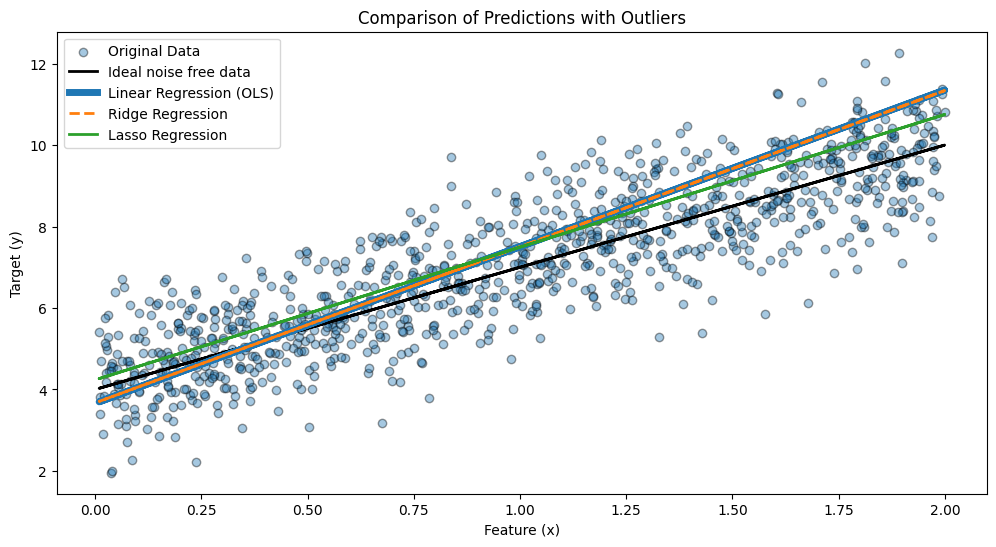

In [8]:
plt.figure(figsize = (12, 6))
# scatter plot of the original data with outliers
plt.scatter(x, y, alpha = 0.4, ec = 'k', label = 'Original Data')
# plot the ideal regression line (noise free data)
plt.plot(x, y_ideal, linewidth = 2, color = 'k', label = 'Ideal noise free data')
# plot predictions from OLS model
plt.plot(x, y_hat_OLS, linewidth = 5, label = 'Linear Regression (OLS)')
# plot predictions from Ridge model
plt.plot(x, y_hat_ridge, linewidth = 2, linestyle = '--', label = 'Ridge Regression')
# plot predictions from lasso regression model
plt.plot(x, y_hat_lasso, linewidth = 2, label = 'Lasso Regression')
plt.xlabel('Feature (x)')
plt.ylabel('Target (y)')
plt.title('Comparison of Predictions with Outliers')
plt.legend()
plt.show()

<h3 style = 'color: red'>Fit Ordinary, Ridge, and Lasso Regression Models</h3>
<h3 style = 'color: red'>Visualize the performance of models without the effect of outliers</h3>

In [9]:
# fit a simple linear regression model
lin_reg = LinearRegression()
lin_reg.fit(x, y)
y_hat_OLS = lin_reg.predict(x)
# fit a ridge regression model (regularization to control large coefficients)
ridge_reg = Ridge(alpha = 1)
ridge_reg.fit(x, y)
y_hat_ridge = ridge_reg.predict(x)
# fit a lasso regression model (regularization to control large coefficients)
lasso_reg = Lasso(alpha = 0.2)
lasso_reg.fit(x, y)
y_hat_lasso = lasso_reg.predict(x)

In [10]:
regression_results(y, y_hat_OLS, 'Ordinary')
regression_results(y, y_hat_ridge, 'Ridge')
regression_results(y, y_hat_lasso, 'Lasso')

Evaluation metrics forOrdinaryLinear Regression
Explained_variance:  0.7492
r2:  0.7492
MAE:  0.7873
MSE:  0.975
RMSE 0.9874
Evaluation metrics forRidgeLinear Regression
Explained_variance:  0.7492
r2:  0.7492
MAE:  0.7874
MSE:  0.975
RMSE 0.9874
Evaluation metrics forLassoLinear Regression
Explained_variance:  0.7191
r2:  0.7191
MAE:  0.8408
MSE:  1.0923
RMSE 1.0451


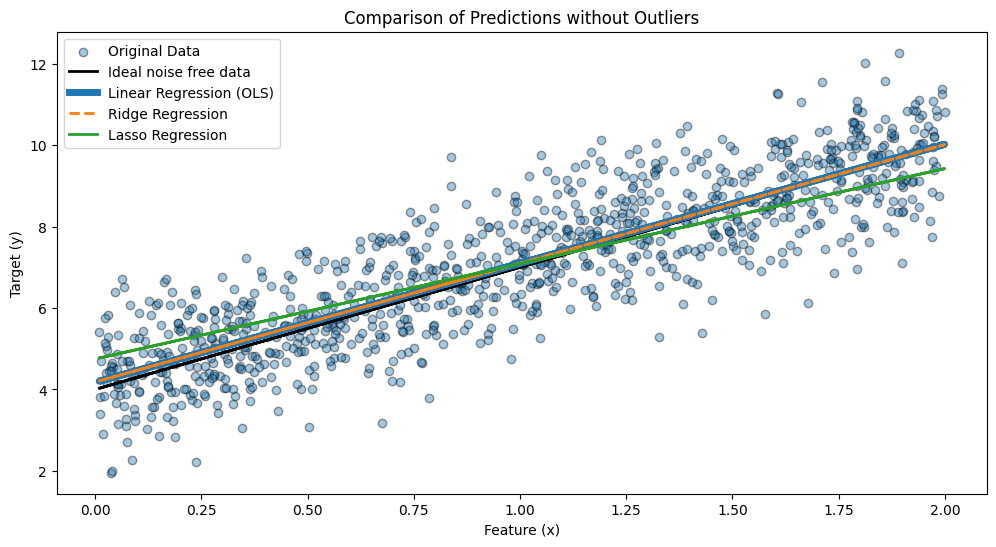

In [11]:
plt.figure(figsize = (12, 6))
# scatter plot of the original data with outliers
plt.scatter(x, y, alpha = 0.4, ec = 'k', label = 'Original Data')
# plot the ideal regression line (noise free data)
plt.plot(x, y_ideal, linewidth = 2, color = 'k', label = 'Ideal noise free data')
# plot predictions from OLS model
plt.plot(x, y_hat_OLS, linewidth = 5, label = 'Linear Regression (OLS)')
# plot predictions from Ridge model
plt.plot(x, y_hat_ridge, linewidth = 2, linestyle = '--', label = 'Ridge Regression')
# plot predictions from lasso regression model
plt.plot(x, y_hat_lasso, linewidth = 2, label = 'Lasso Regression')
plt.xlabel('Feature (x)')
plt.ylabel('Target (y)')
plt.title('Comparison of Predictions without Outliers')
plt.legend()
plt.show()

## Multi-Linear Regression

<h3 style = 'color: red'>Create a high dimensional synthetic dataset with a small number of informative fetures using make_regression</h3>

In [13]:
from sklearn.datasets import make_regression
x, y, ideal_coef = make_regression(n_samples = 100, n_features = 100, n_informative = 10, noise = 10, random_state = 42, coef = True)
# get the ideal predictions based on the informative coefficients used in the regression model
ideal_predictions = x @ ideal_coef     # matrix multiplication: @; the output of ideal_predictions is numpy array with size (100, )
# split the dataset into training and testing sets
x_train, x_test, y_train, y_test, ideal_train, ideal_test = train_test_split(x, y, ideal_predictions, test_size = 0.3, random_state = 42)

In [14]:
lasso = Lasso(alpha = 0.1)
ridge = Ridge(alpha = 1)
linear = LinearRegression()
# fit the models
lasso.fit(x_train, y_train)
ridge.fit(x_train, y_train)
linear.fit(x_train, y_train)
# predict on the test set
y_pred_linear = linear.predict(x_test)
y_pred_ridge = ridge.predict(x_test)
y_pred_lasso = lasso.predict(x_test)

In [15]:
regression_results(y_test, y_pred_linear, 'Ordinary')
regression_results(y_test, y_pred_ridge, 'Ridge')
regression_results(y_test, y_pred_lasso, 'Lasso')

Evaluation metrics forOrdinaryLinear Regression
Explained_variance:  0.4354
r2:  0.4018
MAE:  77.7353
MSE:  9844.2714
RMSE 99.2183
Evaluation metrics forRidgeLinear Regression
Explained_variance:  0.4446
r2:  0.4079
MAE:  76.9622
MSE:  9744.4693
RMSE 98.7141
Evaluation metrics forLassoLinear Regression
Explained_variance:  0.9815
r2:  0.9815
MAE:  13.8855
MSE:  304.644
RMSE 17.4541


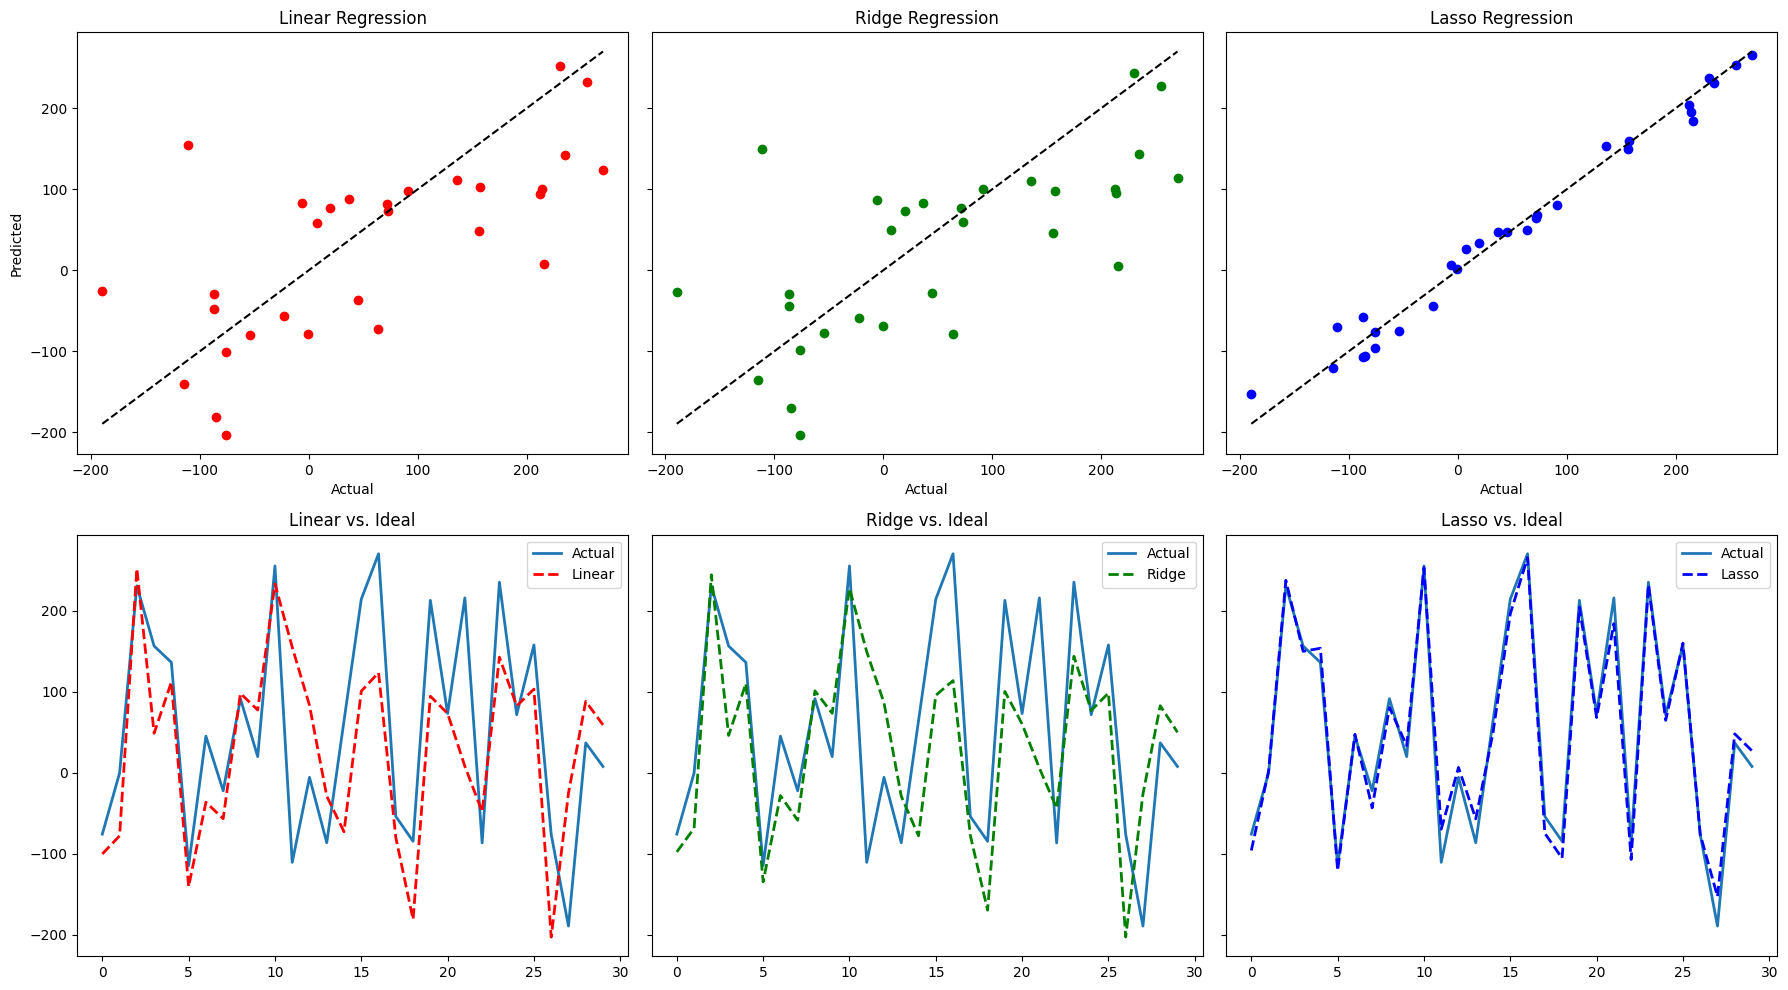

In [16]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10), sharey = True)     # sharey: share the same y-axis along columns
# first plot in the first row
axes[0, 0].scatter(y_test, y_pred_linear, color = 'red', label = 'Linear')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 0].set_title('Linear Regression')
axes[0, 0].set_xlabel('Actual')
axes[0 ,0].set_ylabel('Predicted')
# second plot in the first row
axes[0, 1].scatter(y_test, y_pred_ridge, color = 'green', label = 'Ridge')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 1].set_title('Ridge Regression')
axes[0, 1].set_xlabel('Actual')
# third plot in the first row
axes[0, 2].scatter(y_test, y_pred_lasso, color = 'blue', label = 'Lasso')
axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 2].set_title('Lasso Regression')
axes[0, 2].set_xlabel('Actual')
# first plot in the second row: line plots for predictions
axes[1, 0].plot(y_test, label = 'Actual', lw = 2)
axes[1, 0].plot(y_pred_linear, '--', lw = 2, color = 'red', label = 'Linear')
axes[1, 0].set_title('Linear vs. Ideal')
axes[1, 0].legend()
# second plot in the second row: line plots for predictions
axes[1, 1].plot(y_test, label = 'Actual', lw = 2)
axes[1, 1].plot(y_pred_ridge, '--', lw = 2, color = 'green', label = 'Ridge')
axes[1, 1].set_title('Ridge vs. Ideal')
axes[1, 1].legend()
# third plot in the second row: line plots for predictions
axes[1, 2].plot(y_test, label = 'Actual', lw = 2)
axes[1, 2].plot(y_pred_lasso, '--', lw = 2, color = 'blue', label = 'Lasso')
axes[1, 2].set_title('Lasso vs. Ideal')
axes[1, 2].legend()
plt.tight_layout()
plt.show()

<h3 style = 'color: red'>Model Coefficients</h3>

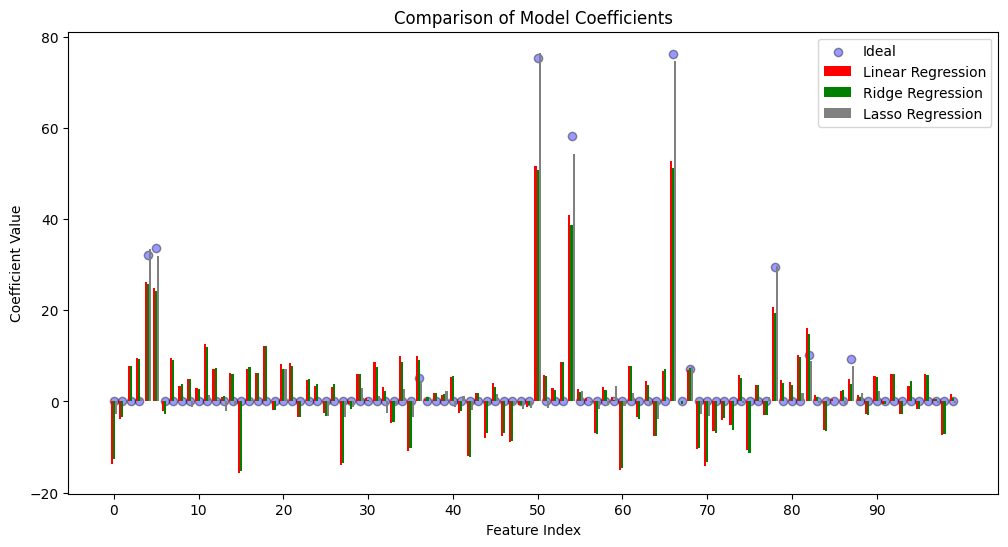

In [22]:
linear_coef = linear.coef_
ridge_coef = ridge.coef_
lasso_coef = lasso.coef_
# plot the coefficients
x_axis = np.arange(len(linear_coef))     # if only input one value for np.arrange(), it will be ending point, starting from 0 with step = 1
x_labels = np.arange(min(x_axis), max(x_axis), 10)
plt.figure(figsize = (12, 6))
plt.scatter(x_axis, ideal_coef, label = 'Ideal', color = 'blue', ec = 'k', alpha = 0.4)
plt.bar(x_axis - 0.25, linear_coef, width = 0.25, label = 'Linear Regression', color = 'red')
plt.bar(x_axis, ridge_coef, width = 0.25, label = 'Ridge Regression', color = 'green')
plt.bar(x_axis + 0.25, lasso_coef, width = 0.25, label = 'Lasso Regression', color = 'gray')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Model Coefficients')
plt.xticks(x_labels)
plt.legend()
plt.show()

<h3 style = 'color: red'>Use Lasso to select the most important features and compare the three different linear regression models</h3>

In [23]:
threshold = 5     # selected by inspection of residuals plot
# create a dataframe containing the lasso model and ideal coefficients
df = pd.DataFrame({'Lasso Coefficient': lasso_coef, 'Ideal Coefficient': ideal_coef})
# mark the selected features
df['Feature Selected'] = df['Lasso Coefficient'].abs() > threshold
print('Feature Identified as Important by Lasso:')
display(df[df['Feature Selected']])
print('\nNonzero Ideal Coefficient Indices:')
display(df[df['Ideal Coefficient'] > 0])

Feature Identified as Important by Lasso:


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
20,7.163636,0.000000,True
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True



Nonzero Ideal Coefficient Indices:


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
36,4.588118,5.166218,False
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True


<h3 style = 'color: red'>Use the threshold to select the most important features for use in modeling</h3>    

In [25]:
important_features = df[df['Feature Selected']].index
# filter features
x_filtered = x[:, important_features]
print('Shape of the filtered feature set:', x_filtered.shape)
# split the dataset into training and testing sets
x_train, x_test, y_train, y_test, ideal_train, ideal_test = train_test_split(x_filtered, y, ideal_predictions, test_size = 0.3, random_state = 42)

Shape of the filtered feature set: (100, 10)


<h3 style = 'color: red'>Fit and apply the three models to the selected features</h3>

In [26]:
lasso = Lasso(alpha = 0.1)
ridge = Ridge(alpha = 1)
linear = LinearRegression()
# fit
lasso.fit(x_train, y_train)
ridge.fit(x_train, y_train)
linear.fit(x_train, y_train)
# predict
y_pred_linear = linear.predict(x_test)
y_pred_ridge = ridge.predict(x_test)
y_pred_lasso = lasso.predict(x_test)

In [27]:
regression_results(y_test, y_pred_linear, 'Ordinary')
regression_results(y_test, y_pred_ridge, 'Ridge')
regression_results(y_test, y_pred_lasso, 'Lasso')

Evaluation metrics forOrdinaryLinear Regression
Explained_variance:  0.9917
r2:  0.9915
MAE:  9.653
MSE:  139.4874
RMSE 11.8105
Evaluation metrics forRidgeLinear Regression
Explained_variance:  0.9909
r2:  0.9905
MAE:  10.1418
MSE:  156.9035
RMSE 12.5261
Evaluation metrics forLassoLinear Regression
Explained_variance:  0.9917
r2:  0.9914
MAE:  9.6928
MSE:  140.803
RMSE 11.866


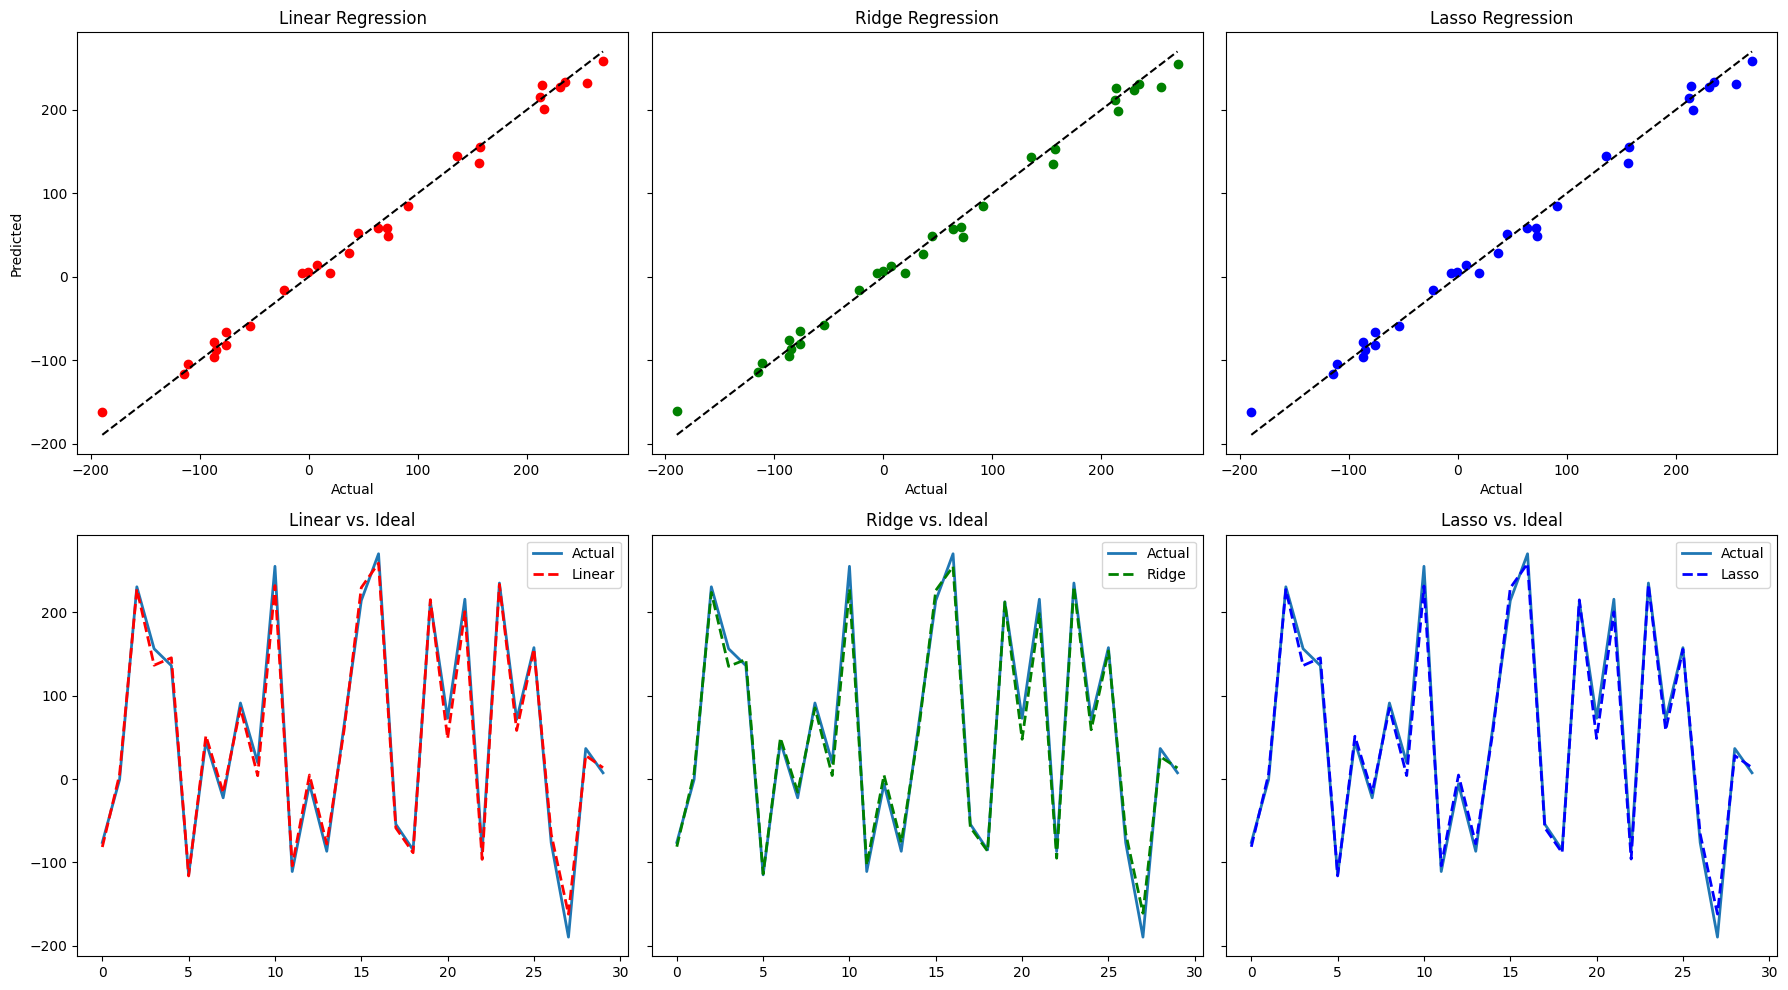

In [28]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10), sharey = True)     # sharey: share the same y-axis along columns
# first plot in the first row
axes[0, 0].scatter(y_test, y_pred_linear, color = 'red', label = 'Linear')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 0].set_title('Linear Regression')
axes[0, 0].set_xlabel('Actual')
axes[0 ,0].set_ylabel('Predicted')
# second plot in the first row
axes[0, 1].scatter(y_test, y_pred_ridge, color = 'green', label = 'Ridge')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 1].set_title('Ridge Regression')
axes[0, 1].set_xlabel('Actual')
# third plot in the first row
axes[0, 2].scatter(y_test, y_pred_lasso, color = 'blue', label = 'Lasso')
axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 2].set_title('Lasso Regression')
axes[0, 2].set_xlabel('Actual')
# first plot in the second row: line plots for predictions
axes[1, 0].plot(y_test, label = 'Actual', lw = 2)
axes[1, 0].plot(y_pred_linear, '--', lw = 2, color = 'red', label = 'Linear')
axes[1, 0].set_title('Linear vs. Ideal')
axes[1, 0].legend()
# second plot in the second row: line plots for predictions
axes[1, 1].plot(y_test, label = 'Actual', lw = 2)
axes[1, 1].plot(y_pred_ridge, '--', lw = 2, color = 'green', label = 'Ridge')
axes[1, 1].set_title('Ridge vs. Ideal')
axes[1, 1].legend()
# third plot in the second row: line plots for predictions
axes[1, 2].plot(y_test, label = 'Actual', lw = 2)
axes[1, 2].plot(y_pred_lasso, '--', lw = 2, color = 'blue', label = 'Lasso')
axes[1, 2].set_title('Lasso vs. Ideal')
axes[1, 2].legend()
plt.tight_layout()
plt.show()